# Validation
---

## Package(s)

In [25]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import pandas as pd
from pathlib import Path

import seaborn as sns

## Helper Function(s)

In [16]:
def make_partitions(pre_dim: int, pooled_dim: int):
    """Partition [pre_dim] into pooled_dim non-empty contiguous blocks."""
    assert pre_dim >= pooled_dim
    base = pre_dim // pooled_dim
    rem = pre_dim % pooled_dim

    parts = []
    start = 0
    for k in range(pooled_dim):
        size = base + (1 if k < rem else 0)
        parts.append(torch.arange(start, start + size, dtype=torch.long))
        start += size
    return parts


class NonnegativeLinear(nn.Module):
    """Linear layer with entrywise nonnegative weights via softplus."""
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.raw_weight = nn.Parameter(
            torch.empty(out_features, in_features).normal_(mean=-2.0, std=0.25)
        )
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None

    @property
    def weight(self):
        return F.softplus(self.raw_weight)

    def forward(self, x):
        return F.linear(x, self.weight, self.bias)


class GatedPReLU(nn.Module):
    r"""
    PReLU_alpha(u) = ReLU(u) - alpha ReLU(-u),
    where alpha in [0,1].
    """
    def __init__(self, dim: int, init_alpha: float = 0.0):
        super().__init__()
        init_alpha = min(max(init_alpha, 1e-4), 1.0 - 1e-4)
        raw = math.log(init_alpha / (1.0 - init_alpha))
        self.raw_alpha = nn.Parameter(torch.full((dim,), raw))

    @property
    def alpha(self):
        return torch.sigmoid(self.raw_alpha)

    def forward(self, x):
        return F.relu(x) - self.alpha * F.relu(-x)


class MaxPoolPartition(nn.Module):
    """Blockwise max-pooling according to a fixed partition."""
    def __init__(self, pre_dim: int, pooled_dim: int):
        super().__init__()
        parts = make_partitions(pre_dim, pooled_dim)
        self.num_parts = len(parts)
        for k, idx in enumerate(parts):
            self.register_buffer(f"idx_{k}", idx)

    def forward(self, z):
        pooled = []
        for k in range(self.num_parts):
            idx = getattr(self, f"idx_{k}")
            pooled.append(z.index_select(dim=1, index=idx).max(dim=1).values)
        return torch.stack(pooled, dim=1)


## Models

In [17]:
class CNFLayer(nn.Module):
    r"""
    x^{ell+1}
      = max_{Pi^{ell}} PReLU_alpha^{bullet}(A^{ell} x^{ell} + b^{ell})
    with A^{ell} >= 0 and alpha in [0,1].
    """
    def __init__(self, in_dim: int, pooled_dim: int, expansion: int = 2, init_alpha: float = 0.0):
        super().__init__()
        pre_dim = expansion * pooled_dim
        assert pre_dim >= pooled_dim

        self.linear = NonnegativeLinear(in_dim, pre_dim, bias=True)
        self.act = GatedPReLU(pre_dim, init_alpha=init_alpha)
        self.pool = MaxPoolPartition(pre_dim, pooled_dim)

    def forward(self, x):
        z = self.linear(x)
        z = self.act(z)
        z = self.pool(z)
        return z


class CNF(nn.Module):
    r"""
    Finite-dimensional implementation of the CNF definition over H = R^input_dim.

    Input layer:
        x^(0)_m = <p_m, x> + constant_shift.

    Hidden layers:
        nonnegative affine -> gated PReLU -> max-pooling.

    Final layer:
        nonnegative affine to R.
    """
    def __init__(
        self,
        input_dim: int,
        M: int,
        pooled_dims=(64, 32),
        expansion: int = 2,
        init_alpha: float = 0.0,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.M = M

        # Trainable measurement vectors p_1,...,p_M in R^input_dim.
        self.p = nn.Parameter(torch.randn(M, input_dim) / math.sqrt(input_dim))

        # This scalar represents the Psi_N(...) constant in the definition.
        self.constant_shift = nn.Parameter(torch.tensor(0.0))

        dims = [M] + list(pooled_dims)
        self.layers = nn.ModuleList([
            CNFLayer(dims[i], dims[i + 1], expansion=expansion, init_alpha=init_alpha)
            for i in range(len(dims) - 1)
        ])

        self.final = NonnegativeLinear(dims[-1], 1, bias=True)

    def forward(self, x):
        x0 = x @ self.p.T + self.constant_shift
        z = x0
        for layer in self.layers:
            z = layer(z)
        return self.final(z).squeeze(-1)


# ------------------------------------------------------------
# Random convex target: larger positive-weight ReLU MLP
# ------------------------------------------------------------

class RandomConvexReLUTarget(nn.Module):
    r"""
    A random convex ReLU MLP.

    First layer has arbitrary affine responses:
        ReLU(W_0 x + b_0), convex coordinatewise because ReLU o affine is convex.

    Subsequent layers use nonnegative weights:
        ReLU(W_l z + b_l), W_l >= 0.

    Final layer is a nonnegative linear combination.
    """
    def __init__(self, input_dim: int, hidden=(128, 128), seed: int = 123):
        super().__init__()
        torch.manual_seed(seed)

        dims = [input_dim] + list(hidden)

        self.W = nn.ParameterList()
        self.b = nn.ParameterList()

        # First layer: arbitrary weights.
        W0 = torch.randn(dims[1], dims[0]) / math.sqrt(dims[0])
        b0 = torch.randn(dims[1]) * 0.2
        self.W.append(nn.Parameter(W0, requires_grad=False))
        self.b.append(nn.Parameter(b0, requires_grad=False))

        # Hidden layers: nonnegative weights.
        for i in range(1, len(dims) - 1):
            Wi = torch.rand(dims[i + 1], dims[i]) / math.sqrt(dims[i])
            bi = torch.randn(dims[i + 1]) * 0.2
            self.W.append(nn.Parameter(Wi, requires_grad=False))
            self.b.append(nn.Parameter(bi, requires_grad=False))

        # Final layer: nonnegative row vector.
        Wout = torch.rand(1, dims[-1]) / math.sqrt(dims[-1])
        bout = torch.randn(1) * 0.2
        self.Wout = nn.Parameter(Wout, requires_grad=False)
        self.bout = nn.Parameter(bout, requires_grad=False)

    def forward(self, x):
        z = F.relu(F.linear(x, self.W[0], self.b[0]))
        for W, b in zip(self.W[1:], self.b[1:]):
            z = F.relu(F.linear(z, W, b))
        return F.linear(z, self.Wout, self.bout).squeeze(-1)


# ------------------------------------------------------------
# Convexity sanity check
# ------------------------------------------------------------

@torch.no_grad()
def max_jensen_violation(model, input_dim: int, n_tests: int = 4096, radius: float = 2.0):
    x = radius * (2 * torch.rand(n_tests, input_dim) - 1)
    y = radius * (2 * torch.rand(n_tests, input_dim) - 1)
    t = torch.rand(n_tests, 1)

    lhs = model(t * x + (1 - t) * y)
    rhs = t.squeeze(-1) * model(x) + (1 - t.squeeze(-1)) * model(y)

    return (lhs - rhs).max().item()

# Run Experiments

## Visual Experiments

In [26]:
d_in = 1
MLP_width = int(500)
ratio_param = .2
CFN_width = 2 * int(round(MLP_width * ratio_param))
N_train = 1000
N_test = 200

GD_iterations = 200

Random convex ReLU MLP target parameters: 252,001
CNF trainable parameters:                 81,402
CNF / target parameter ratio:             0.323
step=   0 | train_mse=5.6639e+03 | test_mse=4.7495e+03 | max_jensen_violation=7.6294e-05


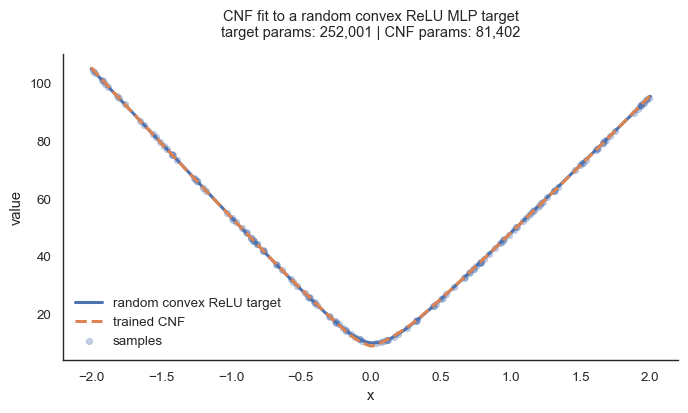

Saved figure to: cnf_fit_random_convex_target.pdf
Target Jensen violation: 7.62939453125e-06
CNF Jensen violation:    2.288818359375e-05


In [27]:
# ------------------------------------------------------------
# Toy experiment
# ------------------------------------------------------------

def count_params(model):
    return sum(p.numel() for p in model.parameters())


def main():
    torch.manual_seed(0)

    # clean white minimal style
    sns.set_theme(
        style="white",
        context="paper",
        font_scale=1.1,
    )

    input_dim = d_in
    n_train = N_train
    n_test = N_test

    target = RandomConvexReLUTarget(input_dim=input_dim, hidden=(MLP_width, MLP_width), seed=2026)
    model = CNF(
        input_dim=input_dim,
        M=CFN_width // 2,
        pooled_dims=(CFN_width, CFN_width // 2),
        expansion=2,
        init_alpha=0.0,
    )

    target_params = count_params(target)
    model_params = count_params(model)

    print(f"Random convex ReLU MLP target parameters: {target_params:,}")
    print(f"CNF trainable parameters:                 {model_params:,}")
    print(f"CNF / target parameter ratio:             {model_params / target_params:.3f}")

    x_train = 4 * torch.rand(n_train, input_dim) - 2
    y_train = target(x_train).detach()

    x_test = torch.linspace(-2, 2, n_test).reshape(-1, 1)
    y_test = target(x_test).detach()

    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)

    for step in range(GD_iterations):
        pred = model(x_train)
        loss = F.mse_loss(pred, y_train)

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % 500 == 0:
            with torch.no_grad():
                test_loss = F.mse_loss(model(x_test), y_test).item()
                viol = max_jensen_violation(model, input_dim)
            print(
                f"step={step:4d} | train_mse={loss.item():.4e} "
                f"| test_mse={test_loss:.4e} | max_jensen_violation={viol:.4e}"
            )

    with torch.no_grad():
        y_hat = model(x_test)

    fig, ax = plt.subplots(figsize=(7, 4.25))

    sns.lineplot(
        x=x_test.squeeze().numpy(),
        y=y_test.numpy(),
        ax=ax,
        linewidth=2.2,
        label="random convex ReLU target",
    )
    sns.lineplot(
        x=x_test.squeeze().numpy(),
        y=y_hat.numpy(),
        ax=ax,
        linewidth=2.2,
        linestyle="--",
        label="trained CNF",
    )
    sns.scatterplot(
        x=x_train[:150].squeeze().numpy(),
        y=y_train[:150].numpy(),
        ax=ax,
        s=22,
        alpha=0.35,
        edgecolor=None,
        label="samples",
    )

    ax.set_title(
        f"CNF fit to a random convex ReLU MLP target\n"
        f"target params: {target_params:,} | CNF params: {model_params:,}",
        pad=12,
    )
    ax.set_xlabel("x")
    ax.set_ylabel("value")
    ax.legend(frameon=False)
    sns.despine(ax=ax)

    plt.tight_layout()

    pdf_name = "cnf_fit_random_convex_target.pdf"
    plt.savefig(pdf_name, format="pdf", bbox_inches="tight")
    plt.show()

    print(f"Saved figure to: {pdf_name}")
    print("Target Jensen violation:", max_jensen_violation(target, input_dim))
    print("CNF Jensen violation:   ", max_jensen_violation(model, input_dim))


if __name__ == "__main__":
    main()

## Dimensional Ablation

In [24]:
# ------------------------------------------------------------
# Multi-run toy experiment
# ------------------------------------------------------------

import pandas as pd
from pathlib import Path


def count_params(model):
    return sum(p.numel() for p in model.parameters())


@torch.no_grad()
def max_jensen_violation(model, input_dim: int, n_tests: int = 4096, radius: float = 2.0, device=None):
    if device is None:
        device = next(model.parameters()).device

    x = radius * (2 * torch.rand(n_tests, input_dim, device=device) - 1)
    y = radius * (2 * torch.rand(n_tests, input_dim, device=device) - 1)
    t = torch.rand(n_tests, 1, device=device)

    lhs = model(t * x + (1 - t) * y)
    rhs = t.squeeze(-1) * model(x) + (1 - t.squeeze(-1)) * model(y)

    return (lhs - rhs).max().item()


def run_single_experiment(
    d_in,
    run_id,
    MLP_width=500,
    ratio_param=.2,
    N_train=1000,
    N_test=200,
    GD_iterations=200,
    lr=1e-3,
    weight_decay=1e-6,
    base_seed=2026,
    device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    seed = base_seed + 1000 * d_in + run_id
    torch.manual_seed(seed)

    input_dim = d_in
    CFN_width = 2 * int(round(MLP_width * ratio_param))

    target = RandomConvexReLUTarget(
        input_dim=input_dim,
        hidden=(MLP_width, MLP_width),
        seed=seed,
    ).to(device)

    model = CNF(
        input_dim=input_dim,
        M=CFN_width // 2,
        pooled_dims=(CFN_width, CFN_width // 2),
        expansion=2,
        init_alpha=0.0,
    ).to(device)

    target_params = count_params(target)
    model_params = count_params(model)

    x_train = 4 * torch.rand(N_train, input_dim, device=device) - 2
    y_train = target(x_train).detach()

    x_test = 4 * torch.rand(N_test, input_dim, device=device) - 2
    y_test = target(x_test).detach()

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    for step in range(GD_iterations):
        pred = model(x_train)
        loss = F.mse_loss(pred, y_train)

        opt.zero_grad()
        loss.backward()
        opt.step()

    with torch.no_grad():
        train_mse = F.mse_loss(model(x_train), y_train).item()
        test_mse = F.mse_loss(model(x_test), y_test).item()
        target_jensen_violation = max_jensen_violation(target, input_dim, device=device)
        cnf_jensen_violation = max_jensen_violation(model, input_dim, device=device)

    return {
        "d_in": d_in,
        "run_id": run_id,
        "MLP_width": MLP_width,
        "CFN_width": CFN_width,
        "N_train": N_train,
        "N_test": N_test,
        "GD_iterations": GD_iterations,
        "target_params": target_params,
        "CNF_params": model_params,
        "CNF_target_param_ratio": model_params / target_params,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "target_jensen_violation": target_jensen_violation,
        "CNF_jensen_violation": cnf_jensen_violation,
    }


def mean_pm_sd(mean, sd, precision=3, sci=True):
    if sci:
        return f"${mean:.{precision}e}\\pm {sd:.{precision}e}$"
    return f"${mean:.{precision}f}\\pm {sd:.{precision}f}$"


def make_latex_table(summary_df):
    table_df = pd.DataFrame({
        "$d_{\\mathrm{in}}$": summary_df["d_in"].astype(int),
        "Target params": summary_df["target_params_mean"].round(0).astype(int),
        "CNF params": summary_df["CNF_params_mean"].round(0).astype(int),
        "Param. ratio": [
            mean_pm_sd(m, s, precision=3, sci=False)
            for m, s in zip(
                summary_df["CNF_target_param_ratio_mean"],
                summary_df["CNF_target_param_ratio_std"],
            )
        ],
        "Train MSE": [
            mean_pm_sd(m, s, precision=3, sci=True)
            for m, s in zip(summary_df["train_mse_mean"], summary_df["train_mse_std"])
        ],
        "Test MSE": [
            mean_pm_sd(m, s, precision=3, sci=True)
            for m, s in zip(summary_df["test_mse_mean"], summary_df["test_mse_std"])
        ],
        "CNF Jensen viol.": [
            mean_pm_sd(m, s, precision=3, sci=True)
            for m, s in zip(
                summary_df["CNF_jensen_violation_mean"],
                summary_df["CNF_jensen_violation_std"],
            )
        ],
    })

    return table_df.to_latex(index=False, escape=False)


def main():
    RUNS = 5
    d_grid = [1, 20, 50, 100]

    MLP_width = 500
    ratio_param = .2
    N_train = 1000
    N_test = 200
    GD_iterations = 200

    output_dir = Path("cnf_experiment_outputs")
    output_dir.mkdir(exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    rows = []

    for d_in in d_grid:
        print(f"\n==============================")
        print(f"Running d_in = {d_in}")
        print(f"==============================")

        for run_id in range(RUNS):
            print(f"Run {run_id + 1}/{RUNS}")

            row = run_single_experiment(
                d_in=d_in,
                run_id=run_id,
                MLP_width=MLP_width,
                ratio_param=ratio_param,
                N_train=N_train,
                N_test=N_test,
                GD_iterations=GD_iterations,
                device=device,
            )

            rows.append(row)

            print(
                f"  train_mse={row['train_mse']:.4e} | "
                f"test_mse={row['test_mse']:.4e} | "
                f"CNF_jensen={row['CNF_jensen_violation']:.4e} | "
                f"params ratio={row['CNF_target_param_ratio']:.3f}"
            )

    raw_df = pd.DataFrame(rows)

    metrics = [
        "target_params",
        "CNF_params",
        "CNF_target_param_ratio",
        "train_mse",
        "test_mse",
        "target_jensen_violation",
        "CNF_jensen_violation",
    ]

    summary_df = (
        raw_df
        .groupby("d_in")[metrics]
        .agg(["mean", "std"])
        .reset_index()
    )

    summary_df.columns = [
        col[0] if col[1] == "" else f"{col[0]}_{col[1]}"
        for col in summary_df.columns
    ]

    raw_path = output_dir / "cnf_raw_results.csv"
    summary_path = output_dir / "cnf_summary_results.csv"
    latex_path = output_dir / "cnf_summary_latex_table.txt"

    raw_df.to_csv(raw_path, index=False)
    summary_df.to_csv(summary_path, index=False)

    latex_table = make_latex_table(summary_df)
    with open(latex_path, "w") as f:
        f.write(latex_table)

    print("\nSaved files:")
    print(f"  Raw results:    {raw_path}")
    print(f"  Summary table:  {summary_path}")
    print(f"  LaTeX table:    {latex_path}")

    print("\nSummary:")
    print(summary_df)

    print("\nLaTeX table:")
    print(latex_table)


if __name__ == "__main__":
    main()

Using device: cpu

Running d_in = 1
Run 1/5
  train_mse=1.2241e+02 | test_mse=1.0995e+02 | CNF_jensen=2.2888e-05 | params ratio=0.323
Run 2/5
  train_mse=3.3793e-01 | test_mse=3.1823e-01 | CNF_jensen=3.0518e-05 | params ratio=0.323
Run 3/5
  train_mse=2.0937e+02 | test_mse=2.0680e+02 | CNF_jensen=2.2888e-05 | params ratio=0.323
Run 4/5
  train_mse=3.7864e+02 | test_mse=3.3554e+02 | CNF_jensen=2.2888e-05 | params ratio=0.323
Run 5/5
  train_mse=2.5933e+02 | test_mse=2.4810e+02 | CNF_jensen=3.8147e-05 | params ratio=0.323

Running d_in = 20
Run 1/5
  train_mse=7.2533e+02 | test_mse=7.1586e+02 | CNF_jensen=-2.7332e-03 | params ratio=0.319
Run 2/5
  train_mse=7.3737e+01 | test_mse=9.7437e+01 | CNF_jensen=-1.0284e-02 | params ratio=0.319
Run 3/5
  train_mse=1.1808e+03 | test_mse=1.3048e+03 | CNF_jensen=-5.2338e-03 | params ratio=0.319
Run 4/5
  train_mse=5.2335e+01 | test_mse=6.4774e+01 | CNF_jensen=-1.3592e-02 | params ratio=0.319
Run 5/5
  train_mse=7.1998e+01 | test_mse=7.2666e+01 | CNF_

---

# Fin

---